# Lalonde Benchmark Results

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/layer6ai-labs/causalfm-survey/blob/main/notebooks/Lalonde_benchmark_results.ipynb)

Loads `scripts/run_benchmark.py`'s full production run: three foundation
models and six metalearners (HPO-tuned), on two Lalonde RealCause cohorts
(CPS, PSID), ten realizations each, about 105 CPU-hours in total. Already
checked into `data/`:

- `benchmark_results_cpu.csv` : all nine models
- `benchmark_results_gpu.csv` : the three foundation models, re-run on GPU

This notebook averages over the ten realizations per cohort, and reproduces
a summary table plus a rank-vs-runtime figure, CATE accuracy vs. compute
cost, at a glance.

In [1]:
import sys, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not Path("causalfm-survey").exists():
    subprocess.run(
        ["git", "clone", "-q", "https://github.com/layer6ai-labs/causalfm-survey.git"],
        check=True,
    )
if IN_COLAB:
    import os
    os.chdir("causalfm-survey")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DATA_DIR = Path("data") if Path("data").exists() else Path("../data")
cpu_df = pd.read_csv(DATA_DIR / "benchmark_results_cpu.csv")
gpu_df = pd.read_csv(DATA_DIR / "benchmark_results_gpu.csv")

FOUNDATION_MODELS = {"CausalPFN (Foundation)", "Do-PFN (Foundation)", "CausalFM (Foundation)"}
NAME_MAP = {
    "CausalPFN (Foundation)": "CausalPFN",
    "Do-PFN (Foundation)": "Do-PFN",
    "CausalFM (Foundation)": "CausalFM",
    "S-learner": "S-Learner",
    "T-learner": "T-Learner",
    "X-learner": "X-Learner",
    "Debiased ML": "Debiased ML",
    "IPW": "IPW",
    "DR (Doubly Robust)": "DR-Learner",
}

print(f"CPU results: {cpu_df.shape[0]} rows ({cpu_df.model.nunique()} models)")
print(f"GPU results: {gpu_df.shape[0]} rows ({gpu_df.model.nunique()} models)")

CPU results: 180 rows (9 models)
GPU results: 60 rows (3 models)


## Summary table (averaged over the 10 realizations per cohort)

**What each column means**

- **PEHE** : shown in units of $1,000 rather than raw dollars.
  Lower is better.
- **ATE relative error** : the absolute error in the estimated average
  treatment effect, as a fraction of the true effect. Lower is better.
- **`pehe_rank`** and **`ate_rel_error_rank`** : each model's rank from 1
  (best) to 9 (worst) among all nine models, computed within every
  realization of that cohort and then averaged over the ten realizations.
  Computed separately per cohort, so a model can rank differently on CPS
  versus PSID.
- **`overall pehe_rank`** and **`overall ate_rel_error_rank`** : the same
  idea, but pooled across both cohorts' twenty realizations together. The
  table is sorted by the PEHE version.

**A couple of things worth knowing before reading the raw numbers too literally**

- IPW only estimates the average effect, not a per-person one, so it has no
  PEHE or PEHE rank (`supports_cate=False`); it's still scored on ATE.
- DR-Learner's average PEHE on the CPS cohort looks enormous mostly because
  of one outlier realization (realization 2: PEHE around 3.1 million versus
  roughly 13,000-48,000 for its other nine CPS runs). Its rank is a fairer summary,
  since a rank isn't dragged around by a single outlier the way an average
  is.

In [2]:
def fmt(mean, sem, precision=2):
    return f"{mean:,.{precision}f} ± {sem:,.{precision}f}"

# PEHE in units of $1,000 -- matches the paper's Table 1 units directly, so
# these numbers are directly comparable to CausalPFN's reported PEHE
cpu_df["pehe_/1000"] = cpu_df["pehe"] / 1000

# rank each model within every (cohort, realization) task, 1 = best
cpu_df["pehe_rank"] = cpu_df.groupby(["cohort", "realization"])["pehe"].rank()
cpu_df["ate_rel_error_rank"] = cpu_df.groupby(["cohort", "realization"])["ate_rel_error"].rank()

metrics = ["pehe_/1000", "pehe_rank", "ate_rel_error", "ate_rel_error_rank"]
grp = cpu_df.groupby(["model", "cohort"])[metrics].agg(["mean", "sem"])

rows = {}
for cohort in sorted(cpu_df["cohort"].unique()):
    for m in metrics:
        mean = grp[(m, "mean")].xs(cohort, level="cohort")
        sem = grp[(m, "sem")].xs(cohort, level="cohort")
        rows[(cohort, m)] = pd.Series({mdl: fmt(mean[mdl], sem[mdl]) for mdl in mean.index})

# overall (both cohorts pooled) ranks -- PEHE rank is used to order the table
overall_pehe_rank = cpu_df.groupby("model")["pehe_rank"].agg(["mean", "sem"])
overall_ate_rank = cpu_df.groupby("model")["ate_rel_error_rank"].agg(["mean", "sem"])
median_runtime = cpu_df.groupby("model")["cate_runtime_s"].median()

summary = pd.DataFrame(rows)
summary.columns = pd.MultiIndex.from_tuples(summary.columns, names=["cohort", "metric"])
summary = summary.sort_index(axis=1, level=0)
summary[("overall", "pehe_rank (1=best of 9)")] = overall_pehe_rank.apply(lambda r: fmt(r["mean"], r["sem"]), axis=1)
summary[("overall", "ate_rel_error_rank (1=best of 9)")] = overall_ate_rank.apply(lambda r: fmt(r["mean"], r["sem"]), axis=1)
summary[("overall", "median_cate_runtime_s")] = median_runtime.round(1)

summary.index = summary.index.map(NAME_MAP)
order = overall_pehe_rank["mean"].sort_values().index.map(NAME_MAP)
# IPW has no PEHE rank (ATE-only) -- keep it, just push it to the end
order = list(order) + [n for n in summary.index if n not in list(order)]
summary = summary.loc[order]
summary

cohort                cps                                                   \
metric      ate_rel_error ate_rel_error_rank       pehe_/1000    pehe_rank   
T-Learner     0.28 ± 0.04        3.20 ± 0.29      9.04 ± 0.08  1.60 ± 0.16   
CausalPFN     0.17 ± 0.03        2.00 ± 0.26      8.97 ± 0.06  1.60 ± 0.27   
Debiased ML   0.34 ± 0.08        2.90 ± 0.46      9.96 ± 0.34  3.00 ± 0.26   
Do-PFN        0.88 ± 0.01        5.90 ± 0.35     11.96 ± 0.09  4.60 ± 0.27   
X-Learner     0.89 ± 0.06        6.60 ± 0.52     11.90 ± 0.40  5.10 ± 0.53   
S-Learner     0.97 ± 0.01        8.20 ± 0.29     12.45 ± 0.11  6.50 ± 0.34   
DR-Learner    0.90 ± 0.04        7.10 ± 0.50  329.98 ± 312.11  7.50 ± 0.22   
CausalFM      0.94 ± 0.00        7.10 ± 0.35     12.34 ± 0.02  6.10 ± 0.31   
IPW           0.15 ± 0.03        2.00 ± 0.33        nan ± nan    nan ± nan   

cohort               psid                                                \
metric      ate_rel_error ate_rel_error_rank    pehe_/1000    pehe_rank   
T-Learner     0.04 ± 0.01        1.30 ± 0.15  13.65 ± 0.47  1.20 ± 0.13   
CausalPFN     0.24 ± 0.04        3.20 ± 0.33  14.00 ± 0.41  1.90 ± 0.18   
Debiased ML   0.29 ± 0.08        3.60 ± 0.34  15.45 ± 1.06  3.40 ± 0.52   
Do-PFN        0.89 ± 0.01        7.10 ± 0.35  20.20 ± 0.39  5.20 ± 0.36   
X-Learner     0.89 ± 0.05        7.80 ± 0.36  20.30 ± 0.60  5.60 ± 0.48   
S-Learner     0.71 ± 0.05        5.90 ± 0.28  20.61 ± 0.41  5.60 ± 0.43   
DR-Learner    0.68 ± 0.05        5.60 ± 0.43  20.28 ± 0.62  5.50 ± 0.40   
CausalFM      0.95 ± 0.00        8.40 ± 0.22  22.27 ± 0.43  7.60 ± 0.22   
IPW           0.08 ± 0.02        2.10 ± 0.23     nan ± nan    nan ± nan   

cohort                      overall                                   \
metric      pehe_rank (1=best of 9) ate_rel_error_rank (1=best of 9)   
T-Learner               1.40 ± 0.11                      2.25 ± 0.27   
CausalPFN               1.75 ± 0.16                      2.60 ± 0.24   
Debiased ML             3.20 ± 0.29                      3.25 ± 0.29   
Do-PFN                  4.90 ± 0.23                      6.50 ± 0.28   
X-Learner               5.35 ± 0.35                      7.20 ± 0.34   
S-Learner               6.05 ± 0.29                      7.05 ± 0.33   
DR-Learner              6.50 ± 0.32                      6.35 ± 0.36   
CausalFM                6.85 ± 0.25                      7.75 ± 0.25   
IPW                       nan ± nan                      2.05 ± 0.20   

cohort                             
metric      median_cate_runtime_s  
T-Learner                  1803.0  
CausalPFN                    18.4  
Debiased ML                1807.9  
Do-PFN                      115.1  
X-Learner                  2707.3  
S-Learner                   901.4  
DR-Learner                 1821.1  
CausalFM                     31.2  
IPW                           NaN

## Figure: accuracy vs. runtime (CPU)

Lower is better on both axes, so a model in the top-left corner is both
accurate (low PEHE rank) and cheap (low runtime). Each marker is a model's
median rank, and the whisker around it spans the 25th to 75th percentile of
its rank across all twenty cohort-and-realization tasks. Colors group the
models: foundation models in blue, HPO-tuned Debiased ML in magenta, and the
HPO-tuned metalearners in orange. Runtime is on a log scale, in CPU seconds
per task.

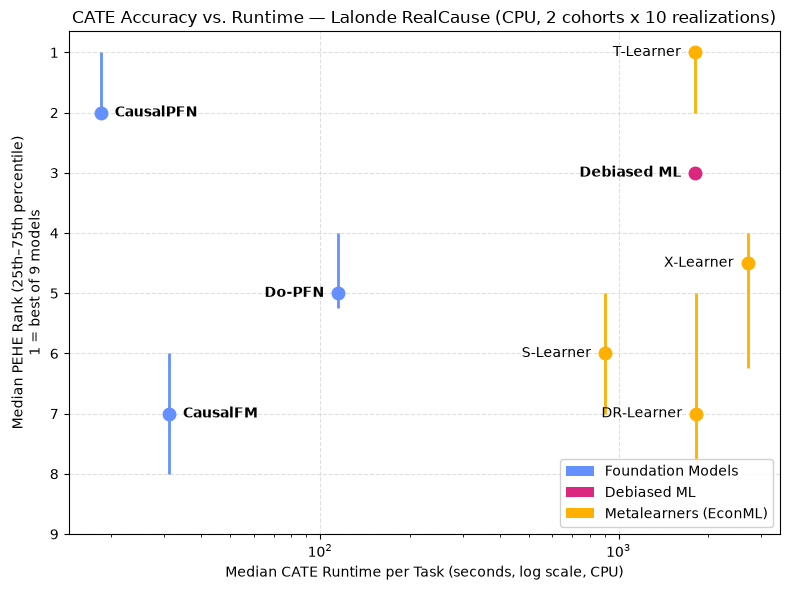

In [3]:
GROUP_COLOR = {
    "Foundation Models": "#648fff",
    "Debiased ML": "#dc267f",
    "Metalearners (EconML)": "#FFB000",
}


def assign_group(model):
    if model in FOUNDATION_MODELS:
        return "Foundation Models"
    if model == "Debiased ML":
        return "Debiased ML"
    return "Metalearners (EconML)"


plot_df = cpu_df.dropna(subset=["pehe_rank"]).copy()
plot_df["group"] = plot_df["model"].apply(assign_group)
plot_df["label"] = plot_df["model"].map(NAME_MAP)

stats = plot_df.groupby("model").agg(
    median_rank=("pehe_rank", "median"),
    q1_rank=("pehe_rank", lambda x: x.quantile(0.25)),
    q3_rank=("pehe_rank", lambda x: x.quantile(0.75)),
    median_time=("cate_runtime_s", "median"),
    group=("group", "first"),
    label=("label", "first"),
).sort_values("median_time")

# Label each point to whichever side (left/right) points away from the
# cluster of the other points, so text sits beside the marker instead of
# stacked on top of it or its whisker.
log_time_mid = np.log10(stats["median_time"]).median() / 2

fig, ax = plt.subplots(figsize=(8, 6))
for _, row in stats.iterrows():
    color = GROUP_COLOR[row["group"]]
    is_highlighted = row["group"] in ("Foundation Models", "Debiased ML")
    ax.vlines(row["median_time"], row["q1_rank"], row["q3_rank"], color=color, linewidth=2)
    ax.plot(row["median_time"], row["median_rank"], "o", color=color, markersize=9, zorder=3)
    on_right_half = np.log10(row["median_time"]) >= log_time_mid
    ax.annotate(
        row["label"],
        (row["median_time"], row["median_rank"]),
        textcoords="offset points",
        xytext=(-10, 0) if on_right_half else (10, 0),
        ha="right" if on_right_half else "left",
        va="center",
        fontsize=10,
        fontweight="bold" if is_highlighted else "normal",
    )

legend_elements = [mpatches.Patch(facecolor=c, label=g) for g, c in GROUP_COLOR.items()]
ax.legend(handles=legend_elements, loc="lower right", frameon=True, framealpha=0.9)

ax.set_xscale("log")
ax.set_xlabel("Median CATE Runtime per Task (seconds, log scale, CPU)")
ax.set_ylabel("Median PEHE Rank (25th–75th percentile)\n1 = best of 9 models")
ax.invert_yaxis()
ax.set_yticks(range(1, 10))
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_title("CATE Accuracy vs. Runtime — Lalonde RealCause (CPU, 2 cohorts x 10 realizations)")
plt.tight_layout()
plt.savefig(DATA_DIR / "figure_rank_vs_runtime.png", dpi=150, bbox_inches="tight")
plt.show()

## Foundation models on GPU

The metalearners' HPO search is CPU-only; the three foundation models were
also run on GPU (`benchmark_results_gpu.csv`). Here's the same CATE task,
GPU versus CPU:

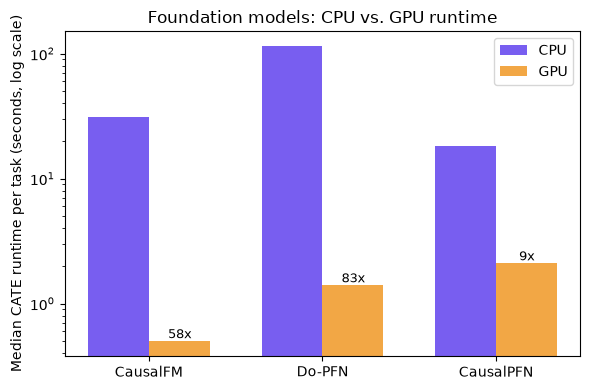

,cpu_s,gpu_s,speedup_x
model,,,
CausalFM,31.2,0.5,58.2
Do-PFN,115.1,1.4,82.6
CausalPFN,18.4,2.1,8.8


In [16]:
cpu_foundation = cpu_df[cpu_df["model"].isin(FOUNDATION_MODELS)].groupby("model")["cate_runtime_s"].median()
gpu_foundation = gpu_df[gpu_df["model"].isin(FOUNDATION_MODELS)].groupby("model")["cate_runtime_s"].median()

speedup = pd.DataFrame({"cpu_s": cpu_foundation, "gpu_s": gpu_foundation})
speedup["speedup_x"] = speedup["cpu_s"] / speedup["gpu_s"]
speedup.index = speedup.index.map(NAME_MAP)
speedup = speedup.sort_values("gpu_s").round(1)

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(speedup))
width = 0.35
ax.bar(x - width / 2, speedup["cpu_s"], width, label="CPU", color="#785ef0")
ax.bar(x + width / 2, speedup["gpu_s"], width, label="GPU", color="#f2a745")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(speedup.index)
ax.set_ylabel("Median CATE runtime per task (seconds, log scale)")
ax.set_title("Foundation models: CPU vs. GPU runtime")
ax.legend()
for i, (_, row) in enumerate(speedup.iterrows()):
    ax.annotate(f"{row['speedup_x']:.0f}x", (i + 0.18, row["gpu_s"]), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

speedup

## Takeaway

CausalPFN stands out on the accuracy-versus-cost trade-off: a median PEHE
rank of about 2 of 9, just behind the best-scoring metalearner (T-Learner,
rank about 1), while taking roughly 18 seconds per task on CPU and about 9
times faster still on GPU. The HPO-tuned metalearners, by comparison, take
900 to 2,700 seconds per task — a cost driven mainly by their fixed
900-second-per-sub-model FLAML search, not by dataset size. Do-PFN and
CausalFM give up some CATE accuracy for a similar order-of-magnitude speed
advantage, and see even larger GPU speedups (roughly 58 to 83 times), since
they're smaller forward-pass models. On ATE specifically, IPW comes out
most accurate (it skips HPO entirely), with T-Learner and CausalPFN close
behind — so on this benchmark, the metalearners' heavy HPO search buys CATE
accuracy, not ATE accuracy. Full analysis and discussion goes in the
paper.